phase 1: eda

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [3]:
# Load dataset
file_path = "../data/movie-ratings.txt"

df = pd.read_csv(
    file_path,
    sep=",",
    header=None,
    names=["userId", "movieId", "categoryId", "reviewId", "rating", "reviewDate"]
)

df.head()

,userId,movieId,categoryId,reviewId,rating,reviewDate
0,1,1,1,1,5,2000-07-12
1,2,1,1,2,5,2000-07-12
2,3,1,1,3,5,2000-07-12
3,4,1,1,4,4,2000-07-12
4,5,1,1,5,4,2000-07-12


In [4]:
print("Number of users:", df["userId"].nunique())
print("Number of movies:", df["movieId"].nunique())
print("Number of ratings:", len(df))

Number of users: 17615
Number of movies: 16121
Number of ratings: 72665


In [5]:
num_users = df["userId"].nunique()
num_movies = df["movieId"].nunique()
num_ratings = len(df)

sparsity = 1 - (num_ratings / (num_users * num_movies))
print("Sparsity:", sparsity)

Sparsity: 0.9997441115684126


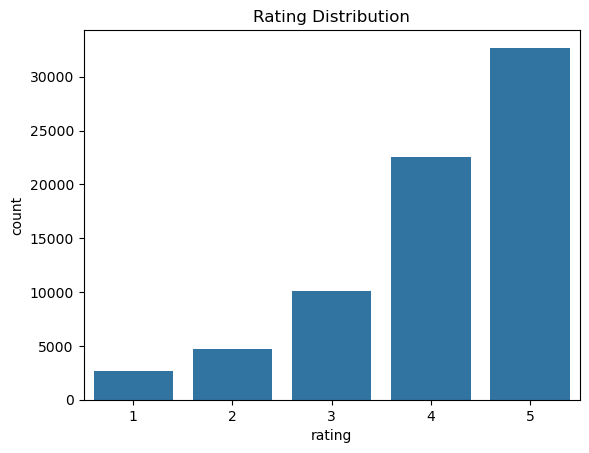

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="rating", data=df)
plt.title("Rating Distribution")
plt.show()

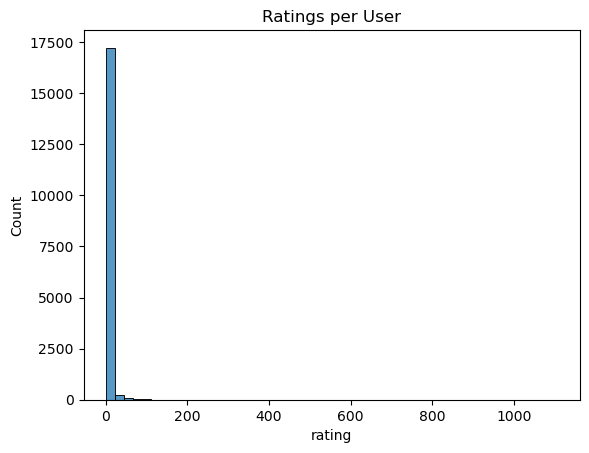

In [7]:
ratings_per_user = df.groupby("userId")["rating"].count()

sns.histplot(ratings_per_user, bins=50)
plt.title("Ratings per User")
plt.show()

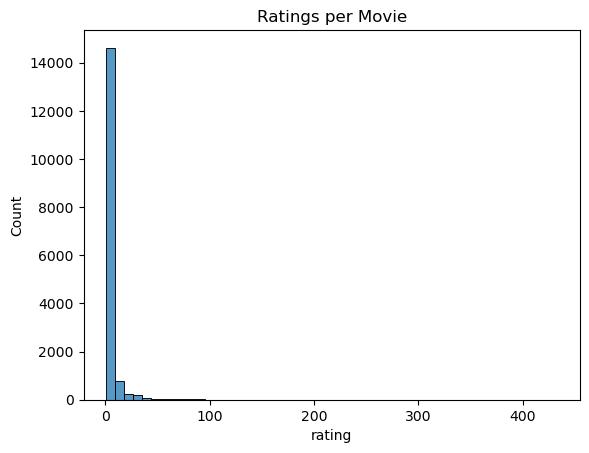

In [8]:
ratings_per_movie = df.groupby("movieId")["rating"].count()

sns.histplot(ratings_per_movie, bins=50)
plt.title("Ratings per Movie")
plt.show()

phase 2: models

In [9]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

In [10]:
global_avg = train["rating"].mean()
print("Global Average Rating:", global_avg)

Global Average Rating: 4.073401912887911


In [11]:
test["prediction"] = global_avg

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test["rating"], test["prediction"]))
mae = mean_absolute_error(test["rating"], test["prediction"])

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.0820577055559708
MAE: 0.8351421604406448


In [13]:
from surprise import Dataset, Reader, KNNBasic

In [14]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(df[["userId", "movieId", "rating"]], reader)

In [15]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [16]:
from surprise import KNNBasic

sim_options = {
    "name": "cosine",
    "user_based": True
}

model = KNNBasic(sim_options=sim_options)
model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [17]:
predictions = model.test(testset)

In [18]:
from surprise import accuracy

rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

RMSE: 1.0839
MAE:  0.8200


SVD Matrix Factorization

In [19]:
from surprise import SVD

In [20]:
svd_model = SVD()
svd_model.fit(trainset)

In [21]:
svd_predictions = svd_model.test(testset)

In [22]:
from surprise import accuracy

svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

RMSE: 0.9548
MAE:  0.7378


In [25]:
rmse_global = 1.0820577055559708
mae_global = 0.8351421604406448

rmse_user = 1.0839
mae_user = 0.8200

svd_rmse = 0.9548
svd_mae = 0.7378

Models Compare

In [26]:
results = pd.DataFrame({
    "Model": ["Global Avg", "User-CF", "SVD"],
    "RMSE": [rmse_global, rmse_user, svd_rmse],
    "MAE": [mae_global, mae_user, svd_mae]
})

results

,Model,RMSE,MAE
0,Global Avg,1.082058,0.835142
1,User-CF,1.083900,0.820000
2,SVD,0.954800,0.737800


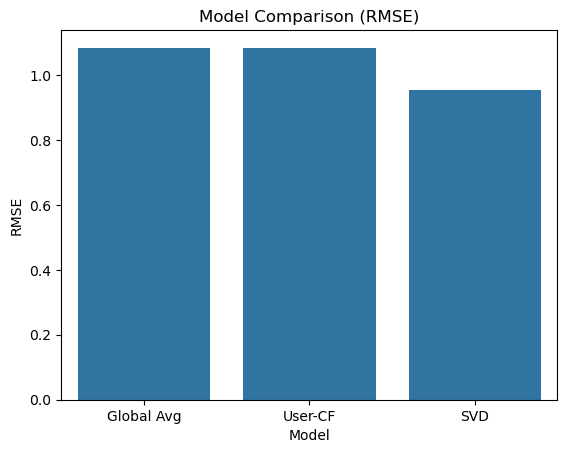

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="RMSE", data=results)
plt.title("Model Comparison (RMSE)")
plt.show()